# **Klasifikasi Penyakit Ayam Menggunakan Ekstraksi Fitur HSV, RGB, GLCM, dan Entropy Berbasis Artificial Neural Network**

Penelitian ini bertujuan untuk mengklasifikasikan penyakit ayam menggunakan pendekatan Computer Vision. Proses dimulai dengan ekstraksi fitur citra yang meliputi fitur warna (HSV dan RGB), fitur tekstur menggunakan Gray Level Co-occurrence Matrix (GLCM), serta fitur kompleksitas menggunakan entropy. Fitur-fitur tersebut kemudian digunakan sebagai input dalam model Artificial Neural Network (ANN) untuk melakukan klasifikasi ke dalam beberapa kategori penyakit, yaitu Sehat, Coccidiosis, NCD, dan Salmonella.

Hasil pengujian menunjukkan bahwa model mampu melakukan klasifikasi dengan tingkat akurasi sebesar 55,3%, dengan performa terbaik pada kelas Sehat dan Coccidiosis, namun masih kurang optimal pada kelas NCD. Hal ini menunjukkan bahwa kombinasi fitur yang digunakan cukup efektif, namun masih perlu pengembangan lebih lanjut untuk meningkatkan performa model.

## **1. Mount Dataset**

Pada tahap ini dilakukan proses mounting Google Drive ke Google Colab menggunakan drive.mount(). Hal ini bertujuan agar file dataset dan hasil pengolahan dapat diakses serta disimpan langsung dari Google Drive selama proses pengolahan data berlangsung.

In [ ]:
# ==========================================
# 1. MOUNT GOOGLE DRIVE
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **2. Import Library**

Pada tahap ini dilakukan import berbagai library yang digunakan dalam proses pengolahan data. Library yang digunakan meliputi OpenCV untuk pengolahan citra, NumPy dan Pandas untuk manipulasi data, serta Matplotlib dan Seaborn untuk visualisasi. Selain itu digunakan metode ekstraksi fitur seperti GLCM dan entropy dari skimage. Proses machine learning memanfaatkan Scikit-learn untuk preprocessing dan evaluasi, serta TensorFlow/Keras untuk membangun model klasifikasi berbasis neural network.

In [ ]:
# ==========================================
# 2. IMPORT LIBRARY
# ==========================================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import graycomatrix, graycoprops
from skimage.measure import shannon_entropy

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam

## **3. Membaca Dataset**

Pada tahap ini ditentukan lokasi dataset yang digunakan, yaitu data training dan data testing yang disimpan di Google Drive. Selain itu dibuat pemetaan kelas (class mapping) untuk mengubah label kategori menjadi nilai numerik agar dapat diproses oleh model. Daftar nama kelas juga disediakan untuk memudahkan interpretasi hasil klasifikasi.

In [ ]:
# ==========================================
# 3. PATH DATASET
# ==========================================
train_dir = '/content/drive/MyDrive/Colab Notebooks/dataset/PenyakitAyam-Train'
test_dir  = '/content/drive/MyDrive/Colab Notebooks/dataset/PenyakitAyam-Test'

class_mapping = {
    'sehat': 0,
    'coccidiosis': 1,
    'ncd': 2,
    'salmonella': 3
}

nama_kelas = ['Sehat', 'Coccidiosis', 'NCD', 'Salmonella']

## **4. Informasi Terkait Dataset**

Pada tahap ini dilakukan pengecekan struktur dataset dengan menampilkan isi folder training dan testing. Proses ini bertujuan untuk memastikan bahwa data telah tersusun dengan benar berdasarkan kelas, serta memastikan file citra tersedia dan dapat diakses sebelum dilakukan proses pengolahan lebih lanjut.

In [ ]:
# ==========================================
# 4. INFO DATASET
# ==========================================
import os

print("Isi Dataset PenyakitAyam-Train")
print(os.listdir(train_dir))

for folder in os.listdir(train_dir):
    folder_path = os.path.join(train_dir, folder)

    if os.path.isdir(folder_path):
        print(f"\nFolder: {folder}")
        print("Isi:", os.listdir(folder_path)[:5])  # tampilkan 5 file pertama

Isi Dataset PenyakitAyam-Train
['coccidiosis', 'sehat', 'ncd', 'salmonella']

Folder: coccidiosis
Isi: ['pcrcocci.200.jpg', 'pcrcocci.249.jpg', 'pcrcocci.250.jpg', 'pcrcocci.131.jpg', 'pcrcocci.251.jpg']

Folder: sehat
Isi: ['pcrhealthy.244.jpg', 'pcrhealthy.297.jpg', 'pcrhealthy.16.jpg', 'pcrhealthy.192.jpg', 'pcrhealthy.147.jpg']

Folder: ncd
Isi: ['pcrncd.9.jpg', 'pcrncd.39.jpg', 'pcrncd.82.jpg', 'pcrncd.4.jpg', 'pcrncd.0.jpg']

Folder: salmonella
Isi: ['pcrsalmo.313.jpg', 'pcrsalmo.196.jpg', 'pcrsalmo.230.jpg', 'pcrsalmo.203.jpg', 'pcrsalmo.321.jpg']


In [ ]:
print("Isi Dataset PenyakitAyam-Test")
print(os.listdir(test_dir))

for folder in os.listdir(test_dir):
    folder_path = os.path.join(test_dir, folder)

    if os.path.isdir(folder_path):
        print(f"\nFolder: {folder}")
        print("Isi:", os.listdir(folder_path)[:5])  # tampilkan 5 file pertama

Isi Dataset PenyakitAyam-Test
['coccidiosis', 'salmonella', 'ncd', 'sehat']

Folder: coccidiosis
Isi: ['cocci.343.jpg', 'cocci.348.jpg', 'cocci.351.jpg', 'cocci.129.jpg', 'cocci.131.jpg']

Folder: salmonella
Isi: ['salmo.110.jpg', 'salmo.101.jpg', 'salmo.128.jpg', 'salmo.115.jpg', 'salmo.136.jpg']

Folder: ncd
Isi: ['ncd.35.jpg', 'ncd.54.jpg', 'ncd.370.jpg', 'ncd.340.jpg', 'ncd.216.jpg']

Folder: sehat
Isi: ['healthy.104.jpg', 'healthy.105.jpg', 'healthy.100.jpg', 'healthy.103.jpg', 'healthy.106.jpg']


## **5. Ektraksi Fitur**

Pada tahap ini dilakukan ekstraksi fitur dari citra menggunakan beberapa metode, yaitu fitur warna (HSV dan RGB), fitur tekstur menggunakan Gray Level Co-occurrence Matrix (GLCM), serta fitur kompleksitas menggunakan entropy. Setiap citra diubah menjadi sejumlah nilai numerik yang merepresentasikan karakteristik citra, sehingga dapat digunakan sebagai input pada proses klasifikasi.

In [ ]:
# ==========================================
# 5. EKSTRAKSI FITUR
# ==========================================
def extract_features(image_path):
    img = cv2.imread(image_path)

    if img is None:
        print("Gagal baca:", image_path)
        return None

    img = cv2.resize(img, (256, 256))

    # HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    # RGB
    r, g, b = img[:,:,2], img[:,:,1], img[:,:,0]

    # Gray
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # GLCM
    glcm = graycomatrix(gray, [1], [0], 256, symmetric=True, normed=True)

    return [
        np.mean(h), np.std(h),
        np.mean(s), np.std(s),
        np.mean(r), np.mean(g), np.mean(b),
        graycoprops(glcm, 'contrast')[0,0],
        graycoprops(glcm, 'homogeneity')[0,0],
        graycoprops(glcm, 'energy')[0,0],
        graycoprops(glcm, 'correlation')[0,0],
        shannon_entropy(gray)
    ]

## **6. Load Dataset**

Pada tahap ini dilakukan proses pembacaan dataset secara keseluruhan. Setiap citra dalam folder diklasifikasikan berdasarkan kelasnya, kemudian dilakukan ekstraksi fitur menggunakan fungsi yang telah dibuat sebelumnya. Hasil ekstraksi fitur disimpan dalam bentuk DataFrame yang berisi fitur numerik dan label kelas, sehingga siap digunakan dalam proses pelatihan model.

In [ ]:
# ==========================================
# 6. LOAD DATA
# ==========================================
def load_dataset(base_dir):
    data = []
    labels = []

    print("\nMembaca folder:", base_dir)
    print("Isi folder:", os.listdir(base_dir))

    for folder in os.listdir(base_dir):
        folder_path = os.path.join(base_dir, folder)

        if not os.path.isdir(folder_path):
            continue

        if folder.lower() not in class_mapping:
            print("Skip:", folder)
            continue

        label = class_mapping[folder.lower()]
        count = 0

        for file in os.listdir(folder_path):
            if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                path = os.path.join(folder_path, file)
                feat = extract_features(path)

                if feat:
                    data.append(feat)
                    labels.append(label)
                    count += 1

        print(f"{folder} -> {count} gambar")

    print("TOTAL DATA:", len(data))

    columns = [
        'mean_h','std_h','mean_s','std_s',
        'mean_r','mean_g','mean_b',
        'contrast','homogeneity','energy','correlation',
        'entropy'
    ]

    df = pd.DataFrame(data, columns=columns)
    df['label'] = labels

    return df

## **7. Ektraksi Dataset**

Pada tahap ini dilakukan proses ekstraksi data dengan memanggil fungsi load_dataset() untuk data training dan testing. Seluruh citra diubah menjadi fitur numerik dan disimpan dalam bentuk DataFrame. Selanjutnya dilakukan pengecekan jumlah data untuk memastikan proses ekstraksi berjalan dengan baik.

In [ ]:
# ==========================================
# 7. EKSTRAKSI DATA
# ==========================================
train_df = load_dataset(train_dir)
test_df  = load_dataset(test_dir)

print("\nJumlah Train:", len(train_df))
print("Jumlah Test:", len(test_df))


Membaca folder: /content/drive/MyDrive/Colab Notebooks/dataset/PenyakitAyam-Train
Isi folder: ['coccidiosis', 'sehat', 'ncd', 'salmonella']
coccidiosis -> 373 gambar
sehat -> 347 gambar
ncd -> 186 gambar
salmonella -> 349 gambar
TOTAL DATA: 1255

Membaca folder: /content/drive/MyDrive/Colab Notebooks/dataset/PenyakitAyam-Test
Isi folder: ['coccidiosis', 'salmonella', 'ncd', 'sehat']
coccidiosis -> 501 gambar
salmonella -> 501 gambar
ncd -> 376 gambar
sehat -> 501 gambar
TOTAL DATA: 1879

Jumlah Train: 1255
Jumlah Test: 1879


## **8. Menyimpan Hasil Ektraksi ke Excel**

Pada tahap ini hasil ekstraksi fitur disimpan ke dalam file Excel untuk data training dan testing. Penyimpanan ini bertujuan untuk memudahkan analisis data, dokumentasi, serta penggunaan kembali tanpa perlu melakukan proses ekstraksi fitur ulang.

In [ ]:
# ==========================================
# 8. SIMPAN KE EXCEL
# ==========================================
train_df.to_excel('/content/drive/MyDrive/fitur_train.xlsx', index=False)
test_df.to_excel('/content/drive/MyDrive/fitur_test.xlsx', index=False)

print("Fitur berhasil disimpan ke Excel!")

Fitur berhasil disimpan ke Excel!


## **9. Membagi Dataset Untuk Training dan Testing**



Pada tahap ini dilakukan pemisahan data menjadi fitur (X) dan label (y). Selanjutnya data training dibagi menjadi data latih dan data validasi menggunakan metode train_test_split dengan perbandingan 80:20. Data testing dipisahkan secara terpisah dan digunakan untuk evaluasi akhir model.

In [ ]:
# ==========================================
# 9. SPLIT DATA
# ==========================================
X = train_df.drop('label', axis=1)
y = train_df['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

## **10. Normalisasi**

Pada tahap ini dilakukan normalisasi data menggunakan metode StandardScaler. Proses ini bertujuan untuk menyamakan skala antar fitur dengan mengubah data sehingga memiliki rata-rata 0 dan standar deviasi 1. Normalisasi dilakukan pada data training menggunakan fit_transform, sedangkan data validasi dan testing hanya menggunakan transform agar tidak terjadi kebocoran data.

In [ ]:
# ==========================================
# 10. NORMALISASI
# ==========================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

## **11. Membuat Model ANN (Artificial Neuron Network)**

Pada tahap ini dibangun model Artificial Neural Network (ANN) menggunakan arsitektur Sequential. Model terdiri dari beberapa hidden layer dengan fungsi aktivasi ReLU, serta menggunakan Batch Normalization dan Dropout untuk meningkatkan stabilitas dan mencegah overfitting. Output layer menggunakan fungsi aktivasi softmax untuk klasifikasi multi-kelas. Model dikompilasi menggunakan optimizer Adam dan loss function sparse categorical crossentropy. Selain itu digunakan Early Stopping untuk menghentikan proses training secara otomatis ketika performa model tidak mengalami peningkatan.

In [ ]:
# ==========================================
# 9. MODEL ANN
# ==========================================
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation='relu'),

    Dense(4, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    min_delta=0.001,
    restore_best_weights=True
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## **12. Proses Training Data**

Pada tahap ini dilakukan proses pelatihan model menggunakan fungsi model.fit(). Model dilatih menggunakan data training selama maksimal 50 epoch dengan ukuran batch 16. Selain itu digunakan data validasi untuk memantau performa model selama proses training. Callback Early Stopping diterapkan untuk menghentikan pelatihan secara otomatis jika tidak terjadi peningkatan performa, sehingga dapat mencegah overfitting.

In [ ]:
# ==========================================
# 12. TRAINING
# ==========================================
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3257 - loss: 1.4959 - val_accuracy: 0.5737 - val_loss: 1.2174
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5189 - loss: 1.1659 - val_accuracy: 0.6414 - val_loss: 1.0852
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5618 - loss: 1.0704 - val_accuracy: 0.6534 - val_loss: 0.9920
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5916 - loss: 1.0248 - val_accuracy: 0.6693 - val_loss: 0.9170
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5996 - loss: 0.9999 - val_accuracy: 0.7012 - val_loss: 0.8679
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6106 - loss: 0.9440 - val_accuracy: 0.7410 - val_loss: 0.8160
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6215 - loss: 0.9465 - val_accuracy: 0.7410 - val_loss: 0.7989
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6285 - loss: 0.9066 - val_accuracy: 0.7371 - val_loss:

## **13. Hasil dan Confusion Matrix**

Pada tahap ini dilakukan evaluasi model menggunakan data testing. Model melakukan prediksi terhadap data uji, kemudian hasilnya dibandingkan dengan label sebenarnya. Evaluasi dilakukan menggunakan classification report yang menampilkan nilai accuracy, precision, recall, dan F1-score. Selain itu digunakan confusion matrix untuk melihat distribusi prediksi model secara visual dalam bentuk heatmap.

59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=== HASIL ===
              precision    recall  f1-score   support

       Sehat       0.56      0.72      0.63       501
 Coccidiosis       0.65      0.76      0.70       501
         NCD       0.14      0.05      0.08       376
  Salmonella       0.55      0.56      0.56       501

    accuracy                           0.55      1879
   macro avg       0.47      0.52      0.49      1879
weighted avg       0.50      0.55      0.52      1879



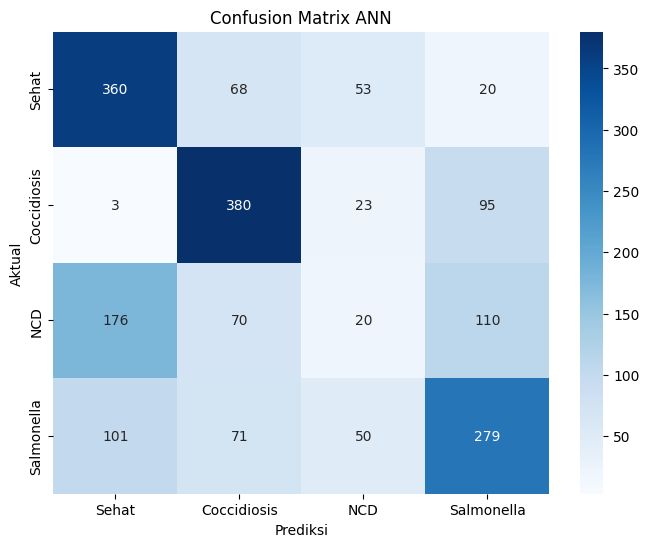

In [ ]:
# ==========================================
# 14. EVALUASI
# ==========================================
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\n=== HASIL ===")
print(classification_report(y_test, y_pred, target_names=nama_kelas))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=nama_kelas,
            yticklabels=nama_kelas)

plt.title("Confusion Matrix ANN")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

📊 Analisis Confusion Matrix

Berdasarkan confusion matrix, model ANN menunjukkan performa yang cukup baik pada kelas Sehat dan Coccidiosis, dengan tingkat recall masing-masing sebesar 71.9% dan 75.8%. Namun, performa pada kelas NCD sangat rendah dengan recall hanya 5.3%, di mana sebagian besar data salah diklasifikasikan sebagai kelas lain, terutama Sehat.

Selain itu, kelas Salmonella memiliki performa sedang dengan recall sebesar 55.7%, namun masih terdapat cukup banyak kesalahan klasifikasi.

Secara keseluruhan, model memperoleh akurasi sebesar 55.3%, yang menunjukkan bahwa model masih kesulitan dalam membedakan beberapa jenis penyakit, khususnya NCD. Oleh karena itu, diperlukan perbaikan pada tahap ekstraksi fitur atau pengembangan model untuk meningkatkan performa klasifikasi.

## **14. Feature Important**

Bagian ini bertujuan untuk menganalisis seberapa besar pengaruh setiap fitur ekstraksi citra terhadap performa prediksi klasifikasi model ANN. Pendekatan yang digunakan adalah **Permutation Feature Importance**.

**Proses Evaluasi:**
1. **Menghitung Baseline:** Mengukur akurasi awal model menggunakan dataset testing utuh (`X_test` dan `y_test`).
2. **Permutasi Nilai:** Mengacak (shuffle) nilai pada satu fitur secara bergantian, sambil mempertahankan nilai fitur lainnya. Hal ini bertujuan untuk menghilangkan informasi prediktif dari fitur yang sedang diuji.
3. **Pengukuran Dampak:** Menghitung ulang akurasi model pada data yang telah diacak.
4. **Kalkulasi Importansi:** Menghitung selisih antara akurasi *baseline* dengan akurasi setelah permutasi. Semakin besar penurunan akurasinya, semakin krusial peran fitur tersebut dalam pengambilan keputusan model.

Hasil visualisasi menunjukkan fitur mana yang memberikan kontribusi terbesar hingga yang tidak memberikan dampak signifikan (atau menjadi *noise*) pada model klasifikasi.

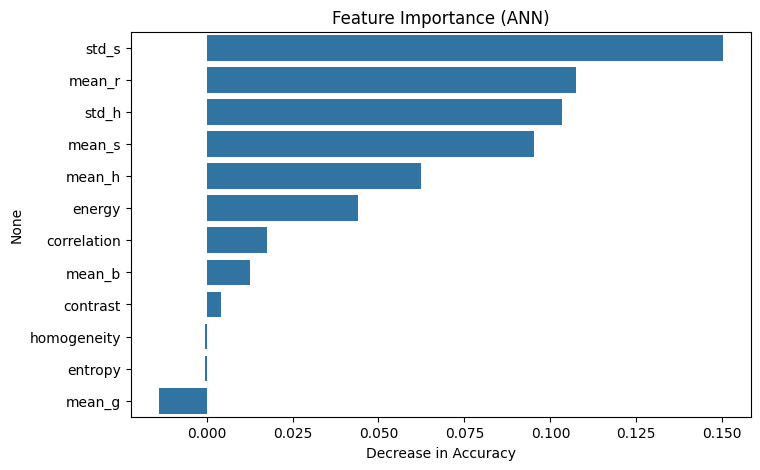

In [ ]:
# ==========================================
# FEATURE IMPORTANCE MANUAL (ANN)
# ==========================================
baseline = model.evaluate(X_test, y_test, verbose=0)[1]

importances = []

for i in range(X_test.shape[1]):
    X_permuted = X_test.copy()
    np.random.shuffle(X_permuted[:, i])

    score = model.evaluate(X_permuted, y_test, verbose=0)[1]
    importance = baseline - score
    importances.append(importance)

feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=feat_imp, y=feat_imp.index)
plt.title("Feature Importance (ANN)")
plt.xlabel("Decrease in Accuracy")
plt.show()

## **15. Kesimpulan**

Berdasarkan hasil penelitian yang telah dilakukan, metode Computer Vision dengan ekstraksi fitur (HSV, RGB, GLCM, dan entropy) serta klasifikasi menggunakan Artificial Neural Network (ANN) mampu mengklasifikasikan penyakit ayam dengan tingkat akurasi sebesar 55,3%.

Model menunjukkan performa yang cukup baik pada kelas Sehat dan Coccidiosis, namun masih lemah dalam mengenali kelas NCD dengan tingkat keberhasilan yang sangat rendah. Hal ini menunjukkan bahwa fitur yang digunakan belum mampu merepresentasikan karakteristik citra secara optimal, terutama untuk membedakan pola penyakit tertentu yang memiliki kemiripan visual.

Secara keseluruhan, model masih mengalami kesulitan dalam membedakan beberapa kelas penyakit, sehingga diperlukan pengembangan lebih lanjut, baik pada tahap ekstraksi fitur maupun arsitektur model, agar dapat meningkatkan akurasi dan performa klasifikasi.